In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SIZE = 16
plt.rcParams["font.family"] = "serif"
plt.rc('font',   size = SIZE)       # controls default text sizes
plt.rc('axes',   labelsize = SIZE)  # fontsize of the x and y labels
plt.rc('xtick',  labelsize = SIZE)  # fontsize of the tick labels
plt.rc('ytick',  labelsize = SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize  = SIZE)  # legend fontsize
plt.rc('figure', titlesize = SIZE)  # fontsize of the figure title

In [16]:
def find_start_row(file_path):
    with open(file_path, "r") as f:
        for i, line in enumerate(f):
            if line.startswith("OPAL"):
                print(f"Data starts at line: {i + 2}")
                return i + 2
    raise ValueError("No line starting with 'OPAL' found.")

def compare_on_grid(opalx, opal, xcol=1, skip_cols=(0, 1), xname="position"):
    import numpy as np
    import pandas as pd

    opalx = opalx.copy()
    opal = opal.copy()

    common_cols = opal.columns.intersection(opalx.columns)

    compare_cols = [
        c for c in common_cols
        if c not in skip_cols
        and pd.api.types.is_numeric_dtype(opal[c])
        and pd.api.types.is_numeric_dtype(opalx[c])
    ]

    opalx_small = opalx[[xcol] + compare_cols].copy()
    opal_small = opal[[xcol] + compare_cols].copy()

    opalx_small = opalx_small.replace([np.inf, -np.inf], np.nan).dropna()
    opal_small = opal_small.replace([np.inf, -np.inf], np.nan).dropna()

    opalx_avg = opalx_small.groupby(xcol, as_index=False).mean()
    opal_avg = opal_small.groupby(xcol, as_index=False).mean()

    opalx_avg = opalx_avg.sort_values(xcol)
    opal_avg = opal_avg.sort_values(xcol)

    xmin = max(opal_avg[xcol].min(), opalx_avg[xcol].min())
    xmax = min(opal_avg[xcol].max(), opalx_avg[xcol].max())

    opal_grid = opal_avg[opal_avg[xcol].between(xmin, xmax)].copy()

    diff = pd.DataFrame()
    diff[xname] = opal_grid[xcol].values

    for col in compare_cols:
        diff[col] = opal_grid[col].values - np.interp(
            opal_grid[xcol].values,
            opalx_avg[xcol].values,
            opalx_avg[col].values,
        )

    return abs(diff)

In [17]:
file_path = '../' 

opal_file = file_path + 'OPAL/' + 'OPAL_SwissFEL-booster-SC.stat'
# opal_file = file_path + 'reference/SwissFEL-booster.stat'
opal = pd.read_csv(opal_file, sep = r"\s+", 
                   skiprows = find_start_row(opal_file), 
                   header = None)

opalx_file = file_path + 'SwissFEL-booster-SC.stat'
opalx = pd.read_csv(opalx_file, sep = r"\s+", 
                    skiprows = find_start_row(opalx_file), 
                    header = None)

diff_vs_position = compare_on_grid(opalx, opal, xcol = 1, skip_cols = (0, 1), xname = "position")

Data starts at line: 303
Data starts at line: 309


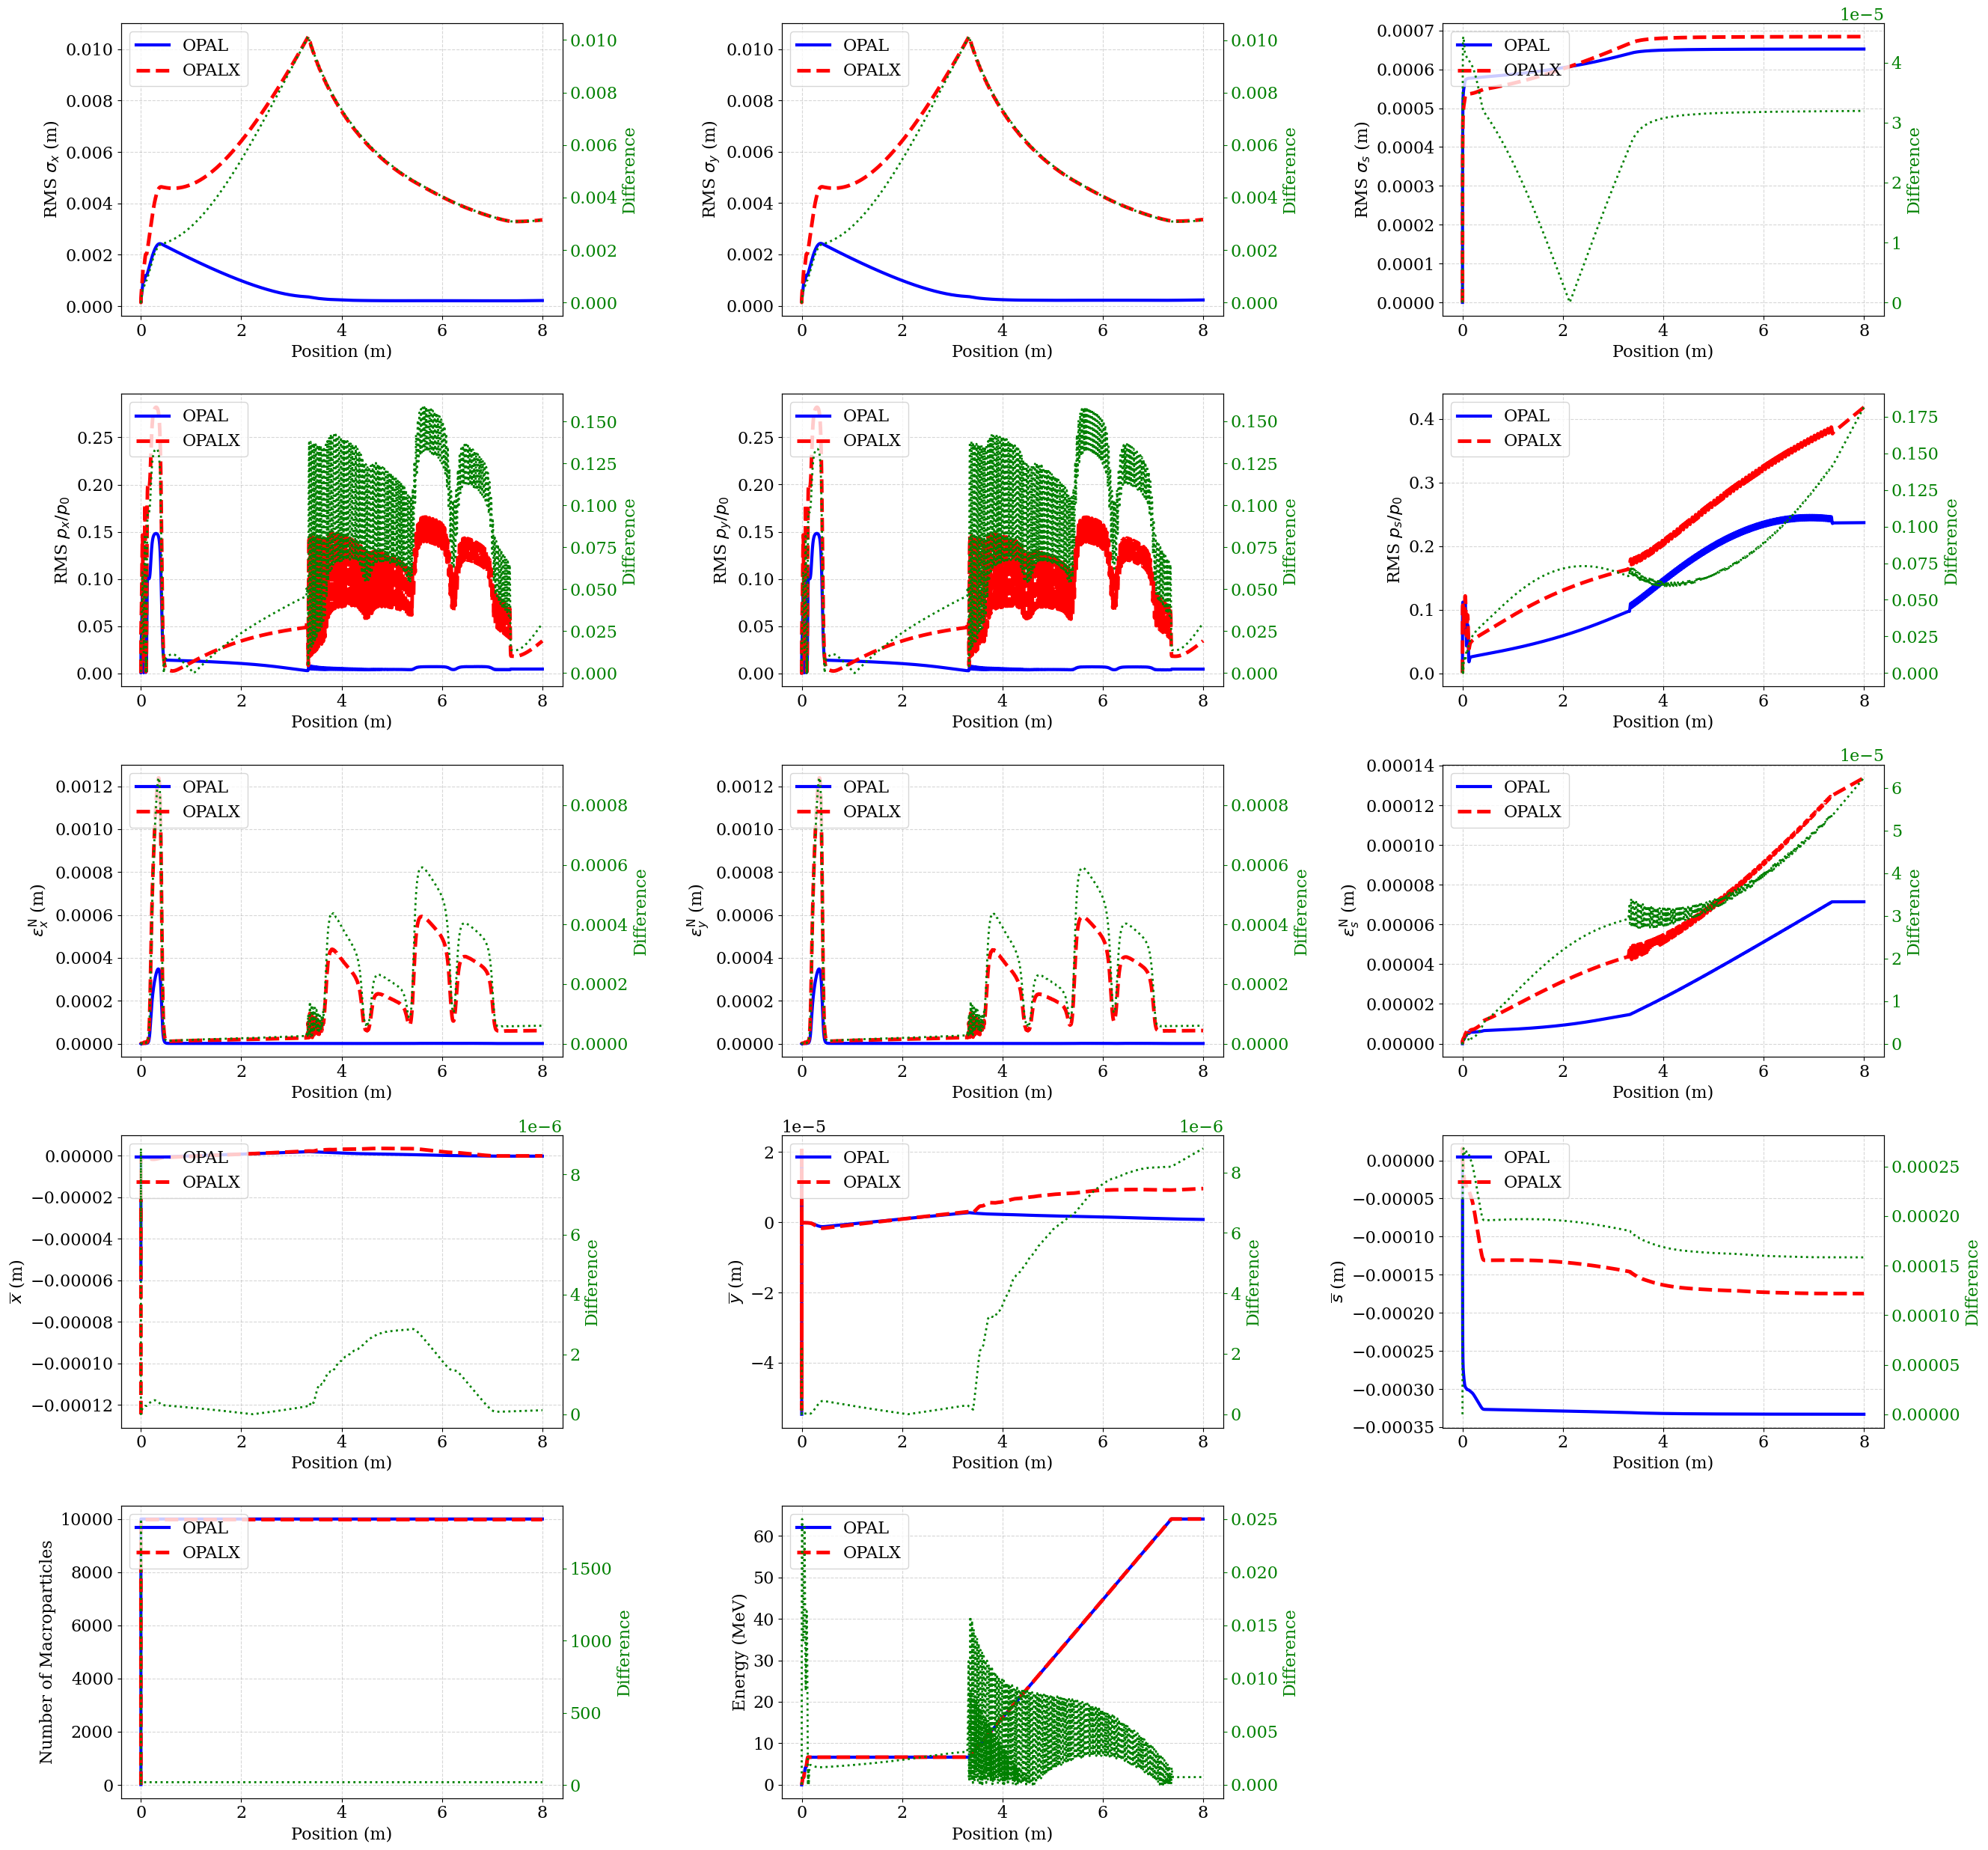

In [18]:
columns_to_plot = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 2, 4]
ylabels = [r'RMS $\sigma_x$ (m)', r'RMS $\sigma_y$ (m)', r'RMS $\sigma_s$ (m)', 
           r'RMS $p_x/p_0$', r'RMS $p_y/p_0$', r'RMS $p_s/p_0$',
           r'$\varepsilon_x^\mathrm{N}$ (m)',r'$\varepsilon_y^\mathrm{N}$ (m)', r'$\varepsilon_s^\mathrm{N}$ (m)',
           r'$\overline{x}$ (m)', r'$\overline{y}$ (m)', r'$\overline{s}$ (m)',
           'Number of Macroparticles', 'Energy (MeV)']

n_plots = len(columns_to_plot)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 5 * nrows))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    ax = axes[i]

    ax.plot(opal[1],  opal[col],  color = 'blue', lw = 3.0, ls = '-',  label = 'OPAL')
    ax.plot(opalx[1], opalx[col], color = 'red',  lw = 3.5, ls = '--', label = 'OPALX')
    
    ax1 = ax.twinx()
    # diff = abs(opal[col] - opalx[col])
    ax1.plot(diff_vs_position["position"], diff_vs_position[col], color = "green", lw = 2, ls=":", label = "OPAL - OPALX")

    
    ax.legend(loc='upper left')
    ax.grid(True, ls='--', alpha=0.5)
    
    ax.set_xlabel('Position (m)')
    ax.set_ylabel(ylabels[i])
    ax1.set_ylabel('Difference', color = 'green')
    ax1.tick_params(axis = 'y', colors = 'green')  

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()
fig.savefig('Multiplot_comparison.png', dpi = 600)

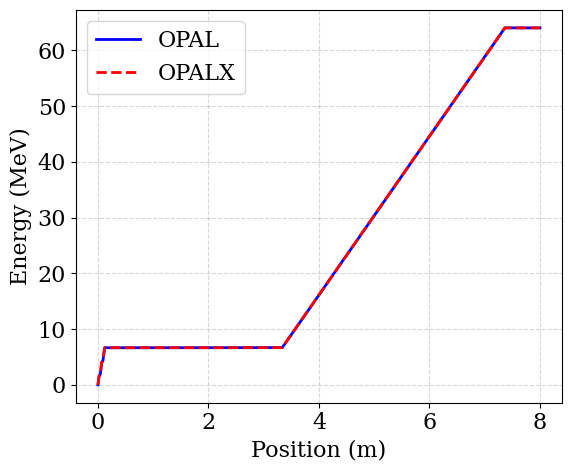

In [19]:
f, ax = plt.subplots(figsize = (6, 5))

ax.plot(opal[1], opal[4], color = 'blue', lw = 2, ls = '-',label = 'OPAL')
ax.plot(opalx[1], opalx[4], color = 'red', lw = 2, ls = '--',label = 'OPALX')

ax.legend()
ax.grid(True, ls = '--', alpha = 0.5)

ax.set_ylabel('Energy (MeV)')
ax.set_xlabel('Position (m)')

f.tight_layout()

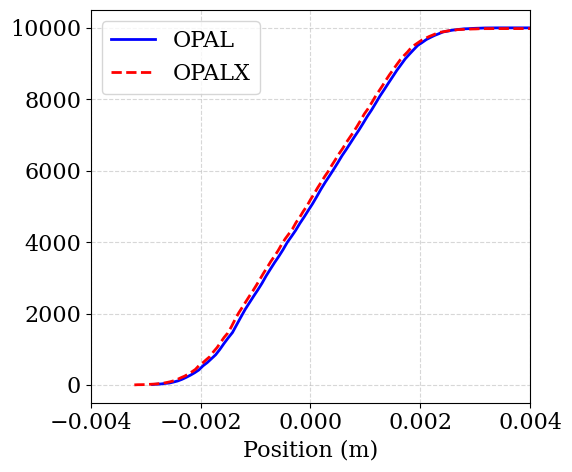

In [20]:
f, ax = plt.subplots(figsize = (6, 5))

ax.plot(opal[0], opal[2], color = 'blue', lw = 2, ls = '-',label = 'OPAL')
ax.plot(opalx[0], opalx[2], color = 'red', lw = 2, ls = '--',label = 'OPALX')

ax.legend()
ax.grid(True, ls = '--', alpha = 0.5)

# ax.set_ylabel('Energy (MeV)')
ax.set_xlabel('Position (m)')

ax.set_xlim(-0.004, 0.004)

f.tight_layout()

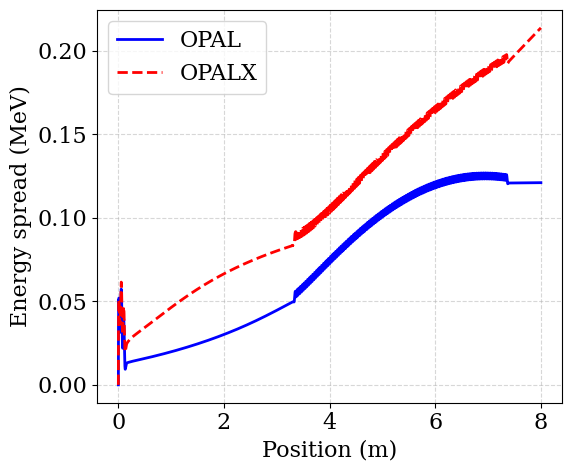

In [21]:
f, ax = plt.subplots(figsize = (6, 5))

ax.plot(opal[1], opal[39], color = 'blue', lw = 2, ls = '-',label = 'OPAL')
ax.plot(opalx[1], opalx[39], color = 'red', lw = 2, ls = '--',label = 'OPALX')

ax.legend()
ax.grid(True, ls = '--', alpha = 0.5)

ax.set_ylabel('Energy spread (MeV)')
ax.set_xlabel('Position (m)')

f.tight_layout()

ValueError: x and y must have same first dimension, but have shapes (13452,) and (13471,)

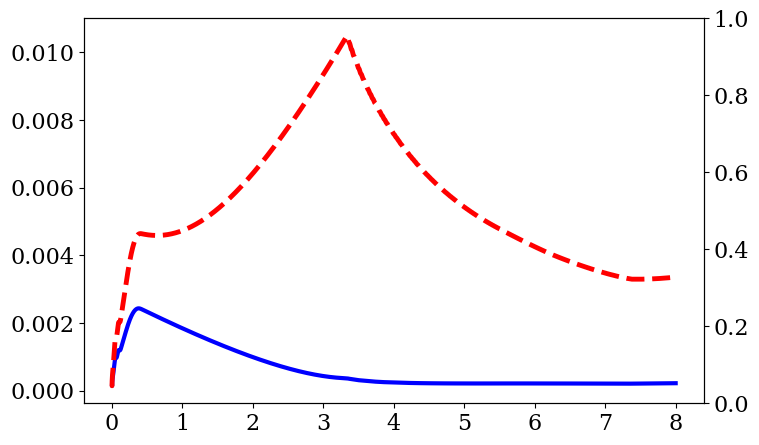

In [22]:
f, ax = plt.subplots(figsize = (8, 5))

ax.plot(opal[1], opal[5], color = 'blue', lw = 3, ls = '-',label = 'OPAL')
ax.plot(opalx[1], opalx[5], color = 'red', lw = 3.5, ls = '--',label = 'OPALX')

diff = abs(opal[5] - opalx[5])
ax1 = ax.twinx()
ax1.plot(opal[1], diff, color = 'green', lw = 2, ls = ':', label = 'Difference (OPAL - OPALX)')


ax.legend()
ax.grid(True, ls = '--', alpha = 0.5)

ax.set_ylabel(r'RMS $\sigma_x$ (m)')
ax.set_xlabel('Position (m)')
ax1.set_ylabel('Difference')

f.tight_layout()

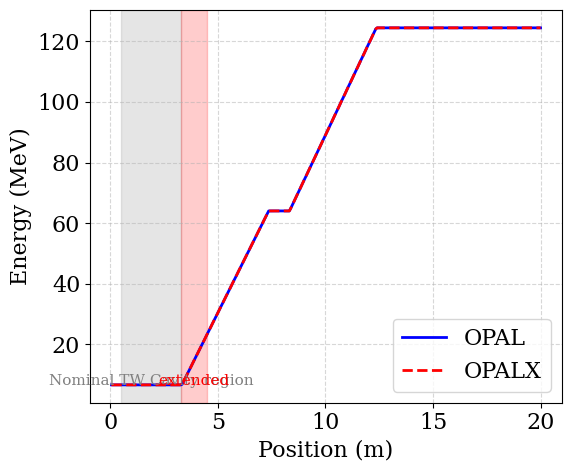

In [12]:
f, ax = plt.subplots(figsize = (6, 5))

ax.plot(opal[1], opal[4], color = 'blue', lw = 2, ls = '-',label = 'OPAL')
ax.plot(opalx[1], opalx[4], color = 'red', lw = 2, ls = '--',label = 'OPALX')

# ax.axvspan(0.5, 3.3, color='grey', alpha=0.2)
# ax.axvspan(3.3, 4.5, color='red', alpha=0.2)

# ax.annotate('Nominal TW Cavity region',
#             xy=(1.9, 6.5), xytext=(1.9, 6.7),
#             color='grey', ha='center', fontsize=11)

# ax.annotate('extended',
#             xy=(3.9, 6.5), xytext=(3.9, 6.7),
#             color='red', ha='center', fontsize=11)

ax.legend()
ax.grid(True, ls = '--', alpha = 0.5)

# ax.set_xlim(1.1, 1.2)
# ax.set_ylim(15.5, 17)
# ax.set_ylim(6, 6.8)
ax.set_ylabel('Energy (MeV)')
ax.set_xlabel('Position (m)')

f.tight_layout()
f.savefig('SwissFEL_energy_comparison.png', dpi = 300)


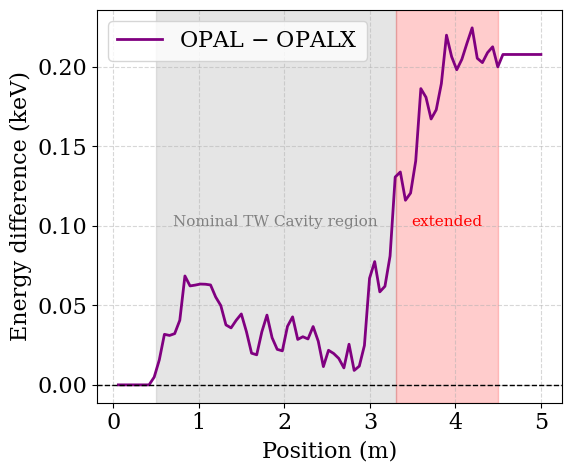

In [15]:
f, ax = plt.subplots(figsize = (6, 5))

diff = abs(opal[4] - opalx[4]) * 1e3

ax.plot(opal[1], diff, color = 'purple', lw = 2, ls = '-', label = r'OPAL $-$ OPALX')
ax.axhline(0, color = 'k', ls = '--', lw = 1)

# ax.axvspan(0.5, 3.3, color = 'grey', alpha = 0.2)
# ax.axvspan(3.3, 4.5, color = 'red', alpha = 0.2)
# ax.annotate('TW Cavity region', xy = (2, 0.0001), xytext = (2, 0.0001), color = 'grey', ha = 'center', fontsize = 12)
# ax.annotate('effective length?', xy = (3.9, 0.0001), xytext = (3.9, 0.0001), color = 'r', ha = 'center', fontsize = 12)

ax.axvspan(0.5, 3.3, color='grey', alpha=0.2)
ax.axvspan(3.3, 4.5, color='red', alpha=0.2)

ax.annotate('Nominal TW Cavity region',
            xy=(1.9, 0.0001*1e3), xytext=(1.9, 0.0001*1e3),
            color='grey', ha='center', fontsize=11)

ax.annotate('extended',
            xy=(3.9, 0.0001*1e3), xytext=(3.9, 0.0001*1e3),
            color='red', ha='center', fontsize=11)

ax.legend()
ax.grid(True, ls = '--', alpha = 0.5)

# ax.set_xlim(0, 0.45)
# ax.set_ylim(-0.05, 0.055)
ax.set_xlabel('Position (m)')
ax.set_ylabel('Energy difference (keV)')

f.tight_layout()
f.savefig('SwissFEL_energy_difference.png', dpi = 300)

In [8]:
# OPAL and OPALX output files have the same format, with 46 columns of data. The columns are as follows:
# [0]: Time (ns)
# [1]: Path length (m)
# [2]: Number of Macro Particles
# [3]: Bunch Charge
# [4]: Mean Bunch Energy (MeV)
# [5]: RMS Beamsize in x (m)
# [6]: RMS Beamsize in y (m)
# [7]: RMS Beamsize in s (m)
# [8]: RMS Normalized Momenta in x (1)
# [9]: RMS Normalized Momenta in y (1)
# [10]: RMS Normalized Momenta in s (1)
# [11]: Normalized Emittance x (m)
# [12]: Normalized Emittance y (m)
# [13]: Normalized Emittance s (m)
# [14]: Mean Beam Position in x (m)
# [15]: Mean Beam Position in y (m)
# [16]: Mean Beam Position in s (m)
# [17]: x coordinate of reference particle in lab cs (m)
# [18]: y coordinate of reference particle in lab cs (m)
# [19]: z coordinate of reference particle in lab cs (m)
# [20]: x momentum of reference particle in lab cs (1)
# [21]: y momentum of reference particle in lab cs (1)
# [22]: z momentum of reference particle in lab cs (1)
# [23]: Max Beamsize in x (m)
# [24]: Max Beamsize in y (m)
# [25]: Max Beamsize in s (m)
# [26]: Correlation xpx (1)
# [27]: Correlation ypy (1)
# [28]: Correlation zpz (1)
# [29]: Dispersion in x (m)
# [30]: Derivative of dispersion in x (1)
# [31]: Dispersion in y (m)
# [32]: Derivative of dispersion in y (1)
# [33]: Bx-Field component of ref particle (T)
# [34]: By-Field component of ref particle (T)
# [35]: Bz-Field component of ref particle (T)
# [36]: Ex-Field component of ref particle (MV/m)
# [37]: Ey-Field component of ref particle (MV/m)
# [38]: Ez-Field component of ref particle (MV/m)
# [39]: Energy spread of the beam (MeV)
# [40]: Time step size (ns)
# [41]: Outside n*sigma of the beam (1)
# [42]: Debye length in the boosted frame (m)
# [43]: Plasma parameter that gives no. of particles in a Debye sphere (1)
# [44]: Temperature of the beam (K)
# [45]: RMS number density of the beam (1)